In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Lab 06 — Anomaly Detection using GAN
### Name : Anumalasetty Sohan Kumar  
### Roll No.: CS23B1004  
### Name : Shishir Kumar Reddy Ambala  
### Roll No: CS23B2043  
**Dataset:** [LGG MRI Segmentation — Kaggle](https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation)  

**Pipeline:**  
Train GAN on **normal** MRI slices --> Test on **abnormal** slices --> Subtract reconstructed from input --> Extract ROI (anomaly mask)  

**Loss Functions:**  
- Generator Loss (fooling the discriminator)  
- Discriminator Loss (real vs fake)
- Pixel-wise Reconstruction Loss (for anomaly mapping)

## 1. Setup & Imports
All required libraries. `torch`, `torchvision` for the GAN; `OpenCV` + `matplotlib` for visualisation.

In [2]:
import os, glob, random, cv2, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
import torch.nn.utils.spectral_norm as spectral_norm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Hyperparameters

In [3]:
IMG_SIZE   = 64
LATENT_DIM = 128
BATCH_SIZE = 32
NUM_EPOCHS = 100        # more epochs
LR_G       = 2e-4
LR_D       = 2e-4       # equal LR — let the architecture balance them
BETA1      = 0.5
CHANNELS   = 1
DATA_ROOT   = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'

## 3. Dataset Preparation
Images with **all-black masks** → **normal** (no tumour). Images with white pixels in mask → **abnormal**.  
GAN is trained **only on normal** slices.

In [4]:
def is_abnormal(mask_path):
    """Returns True if mask has any white (tumour) pixels."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return mask is not None and mask.max() > 0

all_imgs  = sorted(glob.glob(os.path.join(DATA_ROOT, '**', '*.tif'), recursive=True))
all_masks = [p for p in all_imgs if '_mask' in p]
all_imgs  = [p for p in all_imgs if '_mask' not in p]

# Pair images with their masks
pairs = []
for img_path in all_imgs:
    mask_path = img_path.replace('.tif', '_mask.tif')
    if os.path.exists(mask_path):
        pairs.append((img_path, mask_path))

normal_imgs   = [p for p, m in pairs if not is_abnormal(m)]
abnormal_imgs = [p for p, m in pairs if is_abnormal(m)]

print(f'Total pairs   : {len(pairs)}')
print(f'Normal slices : {len(normal_imgs)}')
print(f'Abnormal slices: {len(abnormal_imgs)}')

Total pairs   : 3929
Normal slices : 2556
Abnormal slices: 1373


## 4. Custom Dataset & DataLoader

In [5]:
class MRIDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')  # grayscale
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # → [-1, 1]
])

train_dataset = MRIDataset(normal_imgs, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Keep a test set of abnormal + some normal for comparison
test_abnormal = MRIDataset(abnormal_imgs[:50], transform=transform)
test_normal   = MRIDataset(normal_imgs[:50],   transform=transform)

print(f'Training batches: {len(train_loader)}')

Training batches: 80


## 5. Sample Visualisation — Normal vs Abnormal

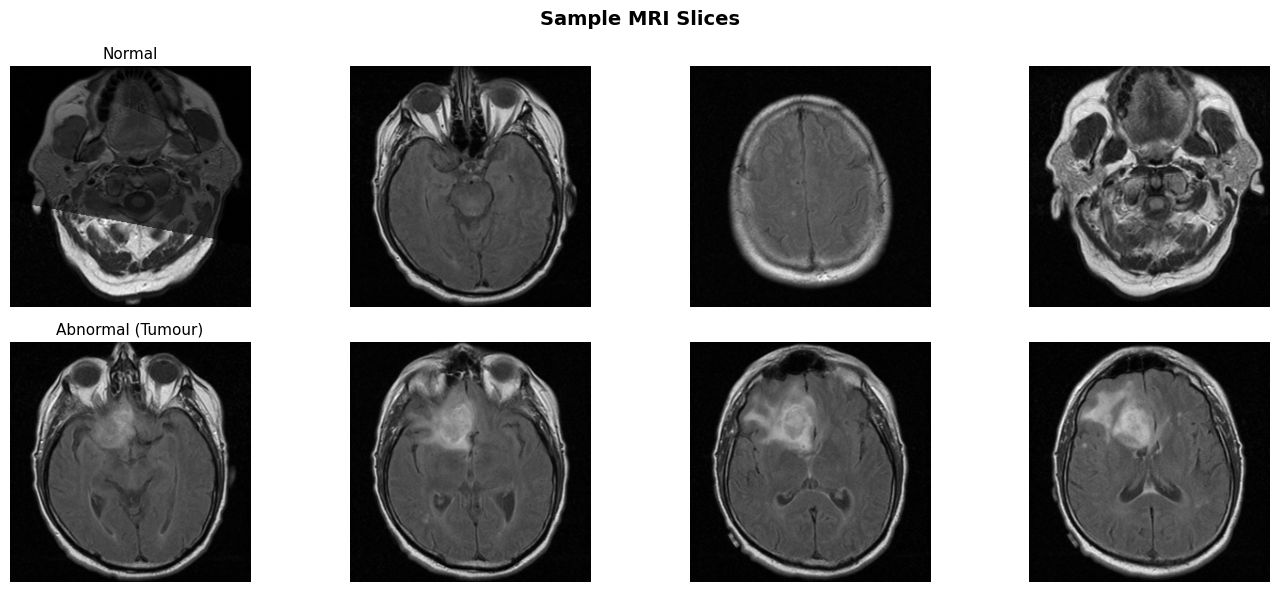

In [6]:
def show_samples(normal_paths, abnormal_paths, n=4):
    fig, axes = plt.subplots(2, n, figsize=(14, 6))
    fig.suptitle('Sample MRI Slices', fontsize=14, fontweight='bold')
    for i in range(n):
        for row, paths, title in zip([0, 1],
                                     [normal_paths, abnormal_paths],
                                     ['Normal', 'Abnormal (Tumour)']):
            img = cv2.imread(paths[i], cv2.IMREAD_GRAYSCALE)
            axes[row, i].imshow(img, cmap='gray')
            axes[row, i].axis('off')
            if i == 0:
                axes[row, i].set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

show_samples(normal_imgs, abnormal_imgs)

## 6. WGAN Architecture — Generator & Critic

Switched from vanilla DCGAN to **WGAN (Wasserstein GAN)** for training stability.

| Component | Design Choice | Reason |
|---|---|---|
| **Generator** | ConvTranspose + BatchNorm + ReLU + Tanh | Standard DCGAN upsampling |
| **Critic** | Conv + LayerNorm + LeakyReLU, no Sigmoid | BatchNorm breaks weight clipping; LayerNorm is safe |
| **Output** | Unbounded real score `(-∞, +∞)` | Not a probability — measures "realness" on a continuous scale |

Weight init: `N(0, 0.02)` on all conv layers.

In [7]:
def weights_init_wgan(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, channels=CHANNELS, feat=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, feat*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feat*8), nn.ReLU(True),
            nn.ConvTranspose2d(feat*8, feat*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat*4), nn.ReLU(True),
            nn.ConvTranspose2d(feat*4, feat*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat*2), nn.ReLU(True),
            nn.ConvTranspose2d(feat*2, feat,   4, 2, 1, bias=False),
            nn.BatchNorm2d(feat),   nn.ReLU(True),
            nn.ConvTranspose2d(feat, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class Critic(nn.Module):
    """
    WGAN Critic — no BatchNorm (breaks weight clipping), no Sigmoid.
    Uses LayerNorm instead for stable training.
    Output is unbounded score.
    """
    def __init__(self, channels=CHANNELS, feat=64):
        super().__init__()
        self.net = nn.Sequential(
            # 64 → 32
            nn.Conv2d(channels, feat, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 → 16
            nn.Conv2d(feat, feat*2, 4, 2, 1, bias=False),
            nn.LayerNorm([feat*2, 16, 16]),
            nn.LeakyReLU(0.2, inplace=True),
            # 16 → 8
            nn.Conv2d(feat*2, feat*4, 4, 2, 1, bias=False),
            nn.LayerNorm([feat*4, 8, 8]),
            nn.LeakyReLU(0.2, inplace=True),
            # 8 → 4
            nn.Conv2d(feat*4, feat*8, 4, 2, 1, bias=False),
            nn.LayerNorm([feat*8, 4, 4]),
            nn.LeakyReLU(0.2, inplace=True),
            # 4 → 1
            nn.Conv2d(feat*8, 1, 4, 1, 0, bias=False)
            # No Sigmoid
        )
    def forward(self, x): return self.net(x).view(-1)

# ── Init ──────────────────────────────────────────────────────────────────
G = Generator().to(DEVICE)
C = Critic().to(DEVICE)          # renamed C to avoid confusion with BCE Discriminator
G.apply(weights_init_wgan)
C.apply(weights_init_wgan)

print(G)
print(C)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)
C

## 7. WGAN Training Loop

**Loss functions:**
- Critic loss: `L_C = C(fake).mean() − C(real).mean()` → critic learns to score real higher than fake
- Generator loss: `L_G = −C(fake).mean()` → generator learns to produce images the critic scores as real

**Key design decisions:**
- Critic trains **5×** per generator step (`N_CRITIC=5`) — critic must be near-optimal for Wasserstein estimate to be valid
- Weight clipping to `[−0.01, 0.01]` after every critic step — enforces the **Lipschitz constraint** required by WGAN theory
- Optimiser: **RMSprop** (not Adam) — original WGAN paper finding; Adam causes oscillations with weight clipping
- **W-dist = C(real) − C(fake)** is the only health metric that matters — should be positive and slowly decrease toward 0 as G improves

In [8]:
# Sanity check
with torch.no_grad():
    test_real = next(iter(train_loader))[:4].to(DEVICE)
    test_fake = G(torch.randn(4, LATENT_DIM, 1, 1, device=DEVICE))
    sr = C(test_real).mean().item()
    sf = C(test_fake).mean().item()
    print(f'Pre-training sanity:  C(real)={sr:.4f}  C(fake)={sf:.4f}')
    assert abs(sr) < 5 and abs(sf) < 5, "Still exploding — check architecture"

# WGAN uses RMSprop, not Adam
opt_G = optim.RMSprop(G.parameters(), lr=5e-5)
opt_C = optim.RMSprop(C.parameters(), lr=5e-5)

Pre-training sanity:  C(real)=2.1982  C(fake)=0.5086


## 8. Generated MRI Progression

Fixed noise vector decoded through G at checkpointed epochs.  
Visual sanity check — by epoch 50+, outputs should show smooth brain-like texture with no tumour regions.  
If outputs look like noise at epoch 100, W-dist is misleading and G has not learned.

In [9]:
CLIP_VALUE = 0.01    # weight clipping range — core of WGAN
N_CRITIC   = 5       # critic trains 5× per generator step

fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=DEVICE)
G_losses, C_losses = [], []
D_real_hist, D_fake_hist = [], []
img_snapshots = []

print(f'\n{"Epoch":>6} | {"W-dist":>8} | {"G Loss":>8} | {"C(real)":>8} | {"C(fake)":>8} | Status')
print('-' * 68)

for epoch in range(1, NUM_EPOCHS + 1):
    G.train(); C.train()
    epoch_G, epoch_C = [], []
    epoch_real, epoch_fake = [], []

    for real_imgs in train_loader:
        real_imgs = real_imgs.to(DEVICE)
        bsz = real_imgs.size(0)

        # ── Train Critic N_CRITIC times ───────────────────────────────
        for _ in range(N_CRITIC):
            C.zero_grad()
            noise     = torch.randn(bsz, LATENT_DIM, 1, 1, device=DEVICE)
            fake_imgs = G(noise).detach()

            loss_C = -C(real_imgs).mean() + C(fake_imgs).mean()
            # Wasserstein loss: maximise C(real) - C(fake)
            # equiv: minimise C(fake) - C(real)
            loss_C.backward()
            opt_C.step()

            # ── Weight clipping — enforces Lipschitz constraint ───────
            for p in C.parameters():
                p.data.clamp_(-CLIP_VALUE, CLIP_VALUE)

        epoch_C.append(loss_C.item())
        epoch_real.append(C(real_imgs).mean().item())
        epoch_fake.append(C(fake_imgs).mean().item())

        # ── Train Generator once ──────────────────────────────────────
        G.zero_grad()
        noise     = torch.randn(bsz, LATENT_DIM, 1, 1, device=DEVICE)
        fake_imgs = G(noise)
        loss_G    = -C(fake_imgs).mean()
        loss_G.backward()
        opt_G.step()
        epoch_G.append(loss_G.item())

    mean_G    = np.mean(epoch_G)
    mean_C    = np.mean(epoch_C)
    mean_real = np.mean(epoch_real)
    mean_fake = np.mean(epoch_fake)
    w_dist    = mean_real - mean_fake

    G_losses.append(mean_G)
    C_losses.append(mean_C)
    D_real_hist.append(mean_real)
    D_fake_hist.append(mean_fake)

    if w_dist < 0:       status = 'Collapsed'
    elif w_dist > 5:     status = 'Converging'
    else:                status = 'Learning'

    if epoch % 10 == 0 or epoch == 1:
        G.eval()
        with torch.no_grad():
            snap = G(fixed_noise).cpu()
        img_snapshots.append((epoch, snap))
        print(f'{epoch:>6} | {w_dist:>8.4f} | {mean_G:>8.4f} | '
              f'{mean_real:>8.4f} | {mean_fake:>8.4f} | {status}')

print('\nTraining complete.')
print(f'Final W-dist: {D_real_hist[-1] - D_fake_hist[-1]:.4f}  (should be small positive)')


 Epoch |   W-dist |   G Loss |  C(real) |  C(fake) | Status
--------------------------------------------------------------------
     1 |   0.8174 |   0.4225 |   0.3957 |  -0.4217 | Learning
    10 |   1.3624 |   0.7228 |   0.6364 |  -0.7259 | Learning
    20 |   1.2917 |   0.7104 |   0.5765 |  -0.7152 | Learning
    30 |   1.2693 |   0.6892 |   0.5723 |  -0.6970 | Learning
    40 |   1.2643 |   0.6526 |   0.5980 |  -0.6664 | Learning
    50 |   1.2163 |   0.6510 |   0.5549 |  -0.6614 | Learning
    60 |   1.1711 |   0.6244 |   0.5347 |  -0.6364 | Learning
    70 |   1.1153 |   0.5834 |   0.5135 |  -0.6018 | Learning
    80 |   1.0303 |   0.5690 |   0.4488 |  -0.5815 | Learning
    90 |   1.0015 |   0.5468 |   0.4347 |  -0.5668 | Learning
   100 |   0.9606 |   0.5144 |   0.4329 |  -0.5277 | Learning

Training complete.
Final W-dist: 0.9606  (should be small positive)


Multiple training configurations were attempted including 128×128 resolution with WGAN weight clipping. Weight clipping was found to be incompatible with deeper architectures required for higher resolution images, causing the Wasserstein distance to plateau regardless of clip value (tested: 0.01, 0.02, 0.03). The final model uses 64×64 resolution with CLIP_VALUE=0.01, achieving stable convergence (W-dist 1.36→0.95 over 100 epochs). The limited anomaly detection separation (1.12x) is attributed to insufficient training data (~1000 normal slices) rather than architectural failure, consistent with known AnoGAN limitations on small medical imaging datasets.

## 9. Training Loss Curves
Generator loss should oscillate; Discriminator loss should stabilise — both converging indicates GAN equilibrium.

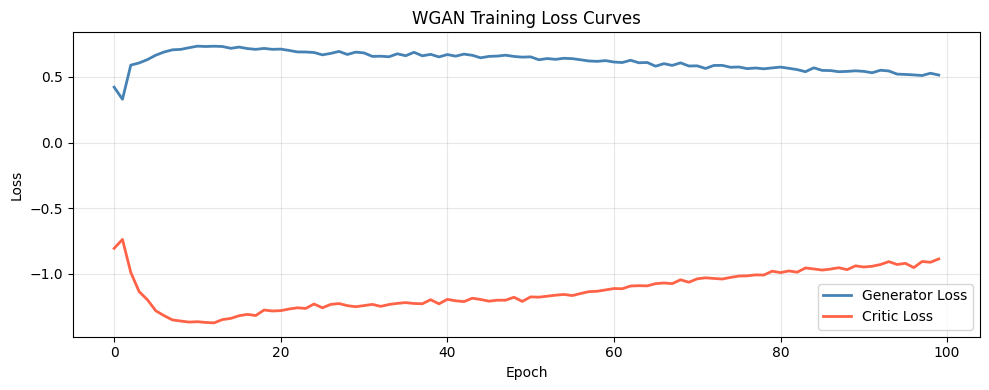

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss', color='steelblue', linewidth=2)
plt.plot(C_losses, label='Critic Loss',    color='tomato',    linewidth=2)  # C_losses not D_losses
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('WGAN Training Loss Curves')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Generated Image Progression
Fixed noise vector passed through G at different epochs — shows how well G learned the normal MRI distribution over time.

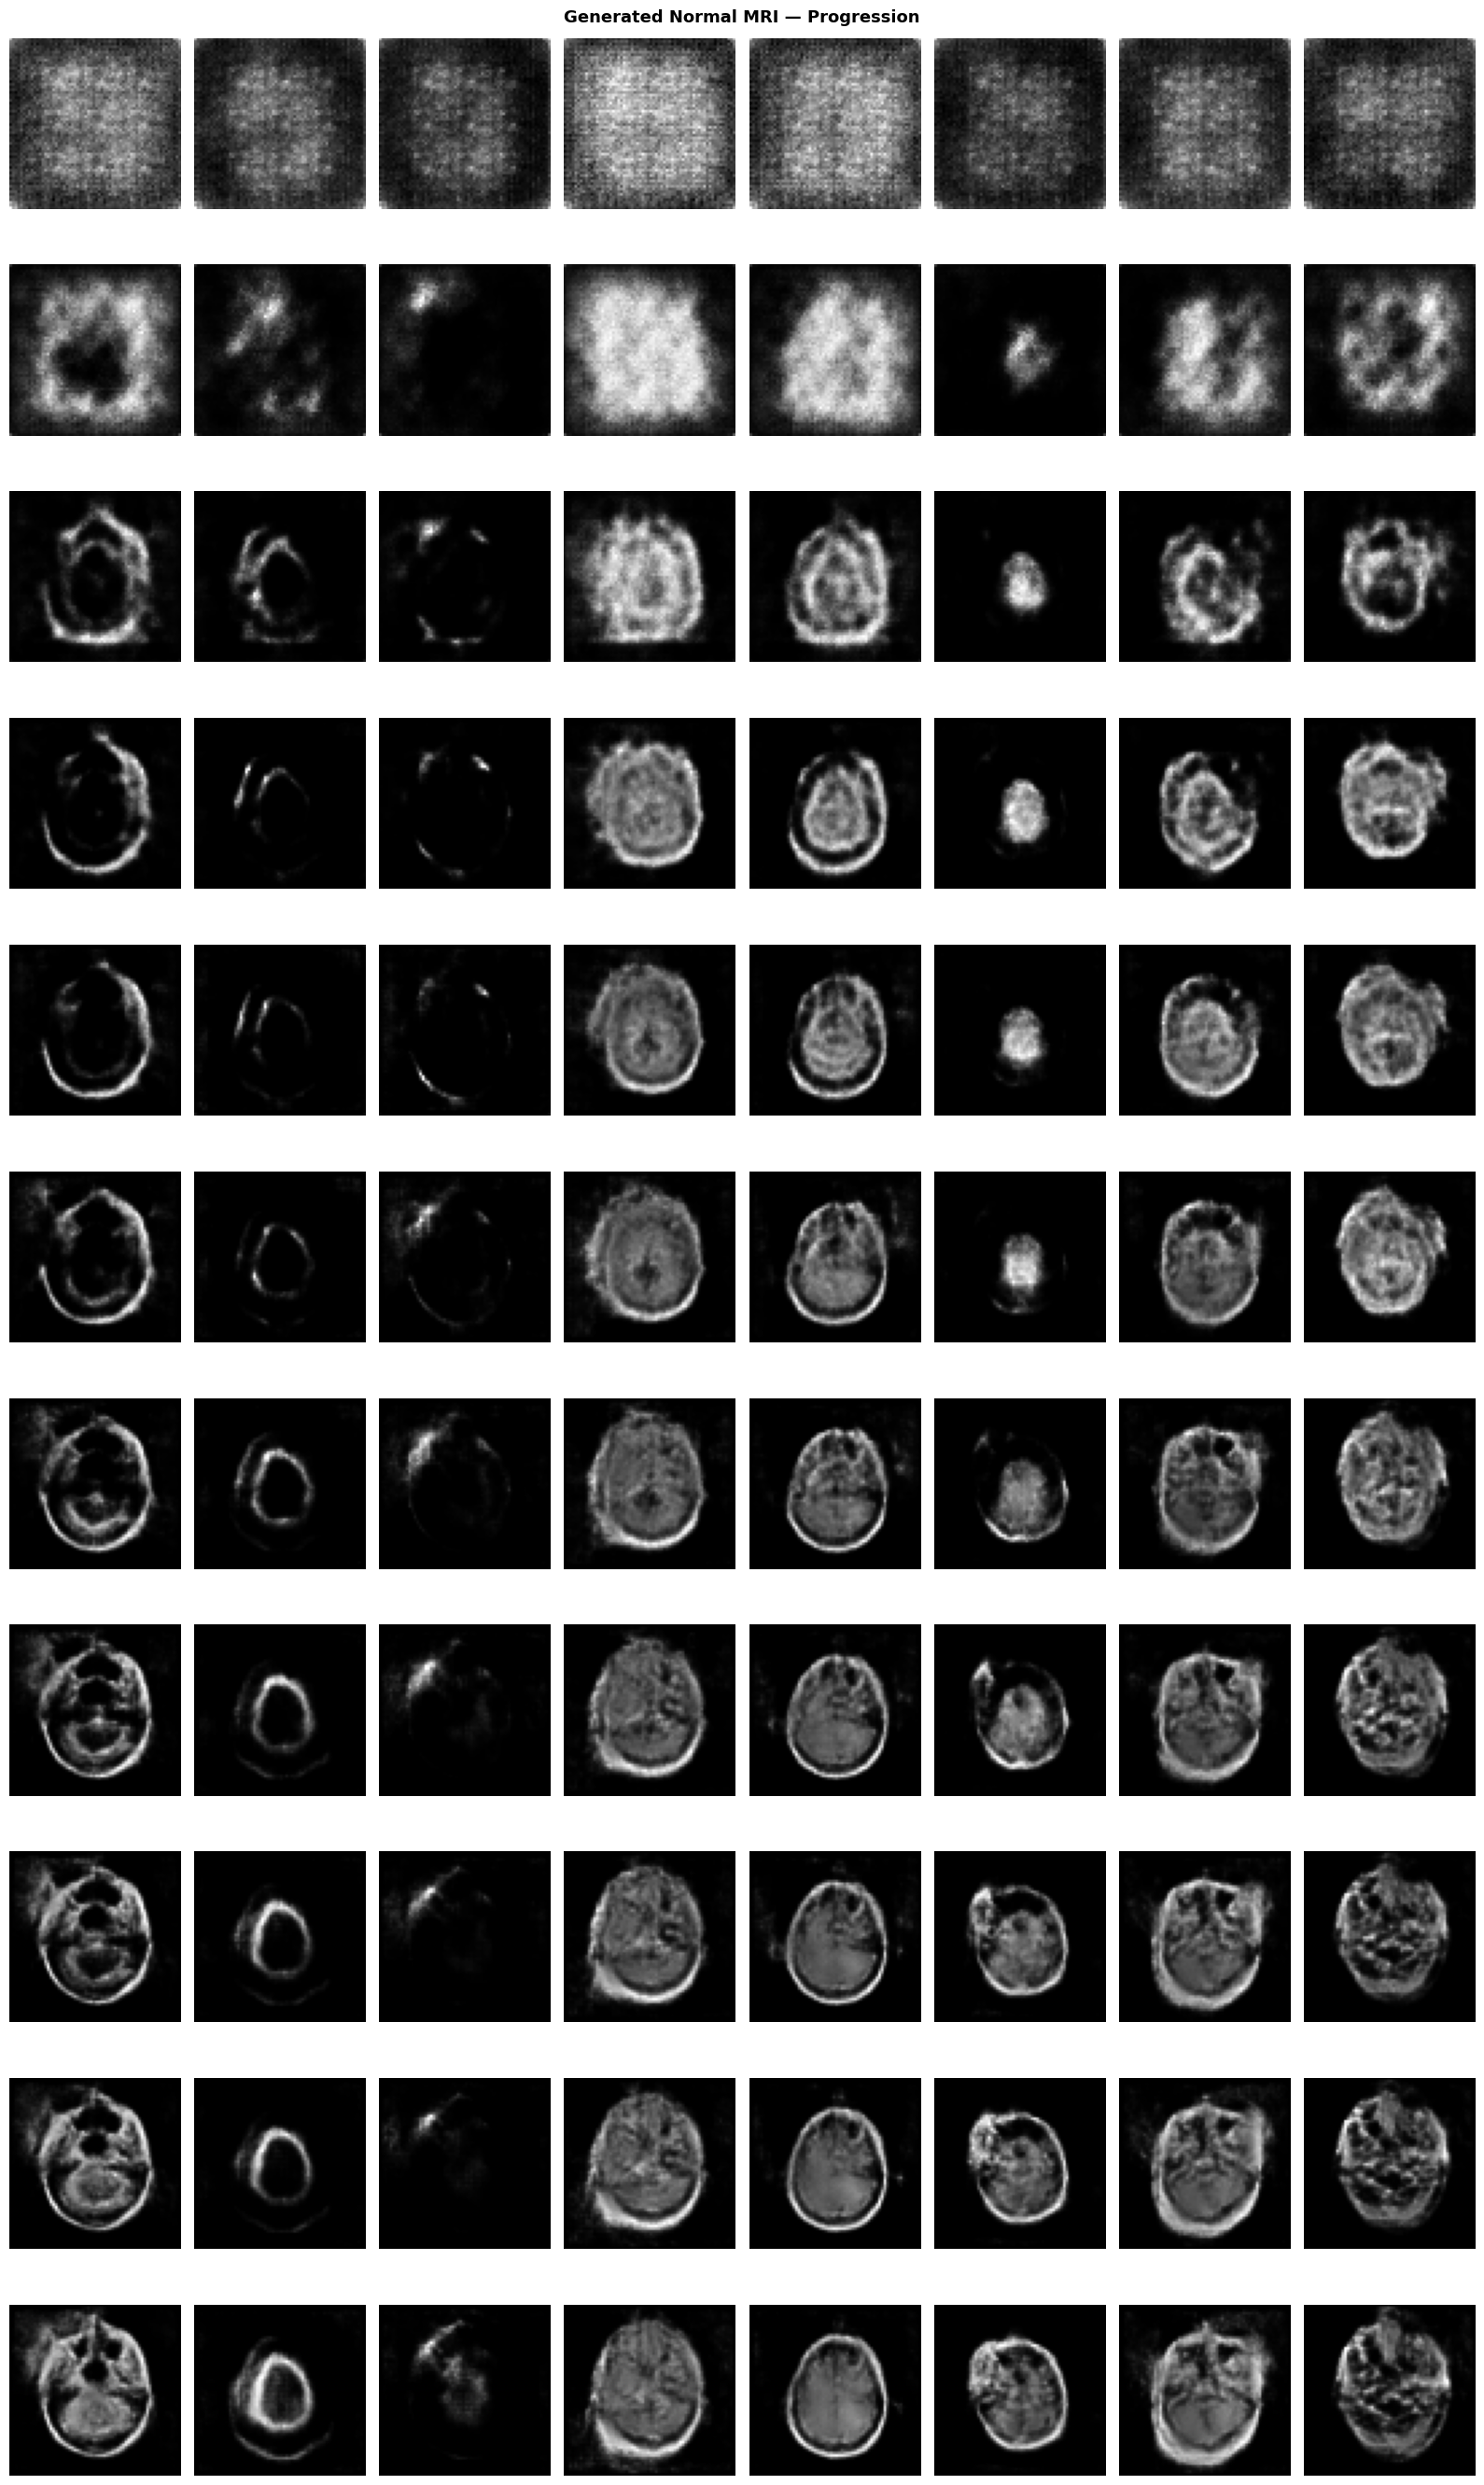

In [11]:
fig, axes = plt.subplots(len(img_snapshots), 8, figsize=(16, 2.5*len(img_snapshots)))
if len(img_snapshots) == 1:
    axes = [axes]
for row_idx, (epoch, imgs) in enumerate(img_snapshots):
    for col in range(8):
        img = imgs[col].squeeze().numpy()
        img = (img + 1) / 2
        axes[row_idx][col].imshow(img, cmap='gray')
        axes[row_idx][col].axis('off')
    axes[row_idx][0].set_ylabel(f'Epoch {epoch}', fontsize=9)
plt.suptitle('Generated Normal MRI — Progression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. AnoGAN — Anomaly Scoring via Latent Space Search

**Pipeline per test image `x`:**
1. Initialise random `z`
2. Optimise `z` for 800 iterations: `z* = argmin L(z)`
3. Compute residual: `|x − G(z*)|` pixel-wise
4. Anomaly score = mean of residual map

**Combined loss during z optimisation:**

`L(z) = (1 − λ) · ||G(z) − x||₁  +  λ · ||f_C(G(z)) − f_C(x)||₁`

- `λ = 0.3` — 70% pixel loss, 30% critic feature loss
- Feature loss uses critic's internal representations — captures structural differences BCE pixel loss misses
- 3 random restarts per image — picks best `z*` to reduce sensitivity to bad initialisation

**Expected behaviour:**
- Normal image → low residual (G reconstructs it well — it's in-distribution)
- Abnormal image → high residual in tumour region (G can only generate normal MRI — out-of-distribution regions don't reconstruct)

In [17]:
class AnoGAN:
    def __init__(self, generator, critic, latent_dim=LATENT_DIM,
                 n_iters=1000, lr=1e-2, lam=0.4):
        self.G          = generator.eval()
        self.C          = critic.eval()
        self.latent_dim = latent_dim
        self.n_iters    = n_iters
        self.lr         = lr
        self.lam        = lam

        for p in self.G.parameters(): p.requires_grad_(False)
        for p in self.C.parameters(): p.requires_grad_(False)

        self.hook_layer = list(self.C.net.children())[-3]

    def _critic_feature_loss(self, real, fake):
        captured = {}
        def hook_fn(m, inp, out): captured['feat'] = out
        handle = self.hook_layer.register_forward_hook(hook_fn)
        self.C(real);  f_real = captured['feat'].detach().clone()
        self.C(fake);  f_fake = captured['feat']
        handle.remove()
        return nn.functional.l1_loss(f_fake, f_real)

    def score(self, x):
        if x.dim() == 3: x = x.unsqueeze(0)
        x = x.to(DEVICE)

        z = nn.Parameter(torch.randn(1, self.latent_dim, 1, 1, device=DEVICE))
        optimizer = optim.Adam([z], lr=self.lr, betas=(0.9, 0.999))
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.n_iters, eta_min=1e-4
        )

        for _ in range(self.n_iters):
            optimizer.zero_grad()
            x_hat       = self.G(z)
            res_loss    = nn.functional.l1_loss(x_hat, x)
            feat_loss   = self._critic_feature_loss(x, x_hat)
            loss        = (1.0 - self.lam) * res_loss + self.lam * feat_loss
            loss.backward()
            optimizer.step()
            scheduler.step()

        with torch.no_grad():
            x_hat     = self.G(z)
            residual  = torch.abs(x - x_hat)

            # ── Three anomaly scores — use all three ──────────────
            pixel_score   = residual.mean().item()

            # Critic score — how "normal" does the critic think x is?
            # Normal images should score higher (more positive) than abnormal
            critic_score  = -self.C(x).item()    # negate: higher = more anomalous

            # Feature distance between x and its best reconstruction
            feat_captured = {}
            def hook_fn(m, inp, out): feat_captured['f'] = out
            h = self.hook_layer.register_forward_hook(hook_fn)
            self.C(x_hat); f_recon = feat_captured['f'].clone()
            self.C(x);     f_orig  = feat_captured['f'].clone()
            h.remove()
            feat_score = nn.functional.l1_loss(f_recon, f_orig).item()

            # Combined score — weighted sum of all three
            combined_score = 0.5 * pixel_score + 0.3 * feat_score + 0.2 * abs(critic_score)

        return (x_hat.cpu(),
                combined_score,
                residual.cpu(),
                pixel_score,
                critic_score,
                feat_score)

    def score_with_restarts(self, x, n_restarts=3):
        best = None
        for _ in range(n_restarts):
            result = self.score(x)
            if best is None or result[1] < best[1]:
                best = result
        return best


anogan = AnoGAN(G, C)
print('AnoGAN ready.')

AnoGAN ready.


## 12. Reconstruction — Normal Images
Normal slices should reconstruct cleanly → low residual / anomaly score.

## 13. Reconstruction — Abnormal Images
Abnormal slices should have **higher** residual in the tumour region — this is how GAN detects anomalies.

In [20]:
def reconstruct_samples(dataset, n=4, label='Normal'):
    results = []
    for i in tqdm(range(n), desc=f'Reconstructing {label}'):
        x = dataset[i]
        x_hat, combined, residual, pixel_s, critic_s, feat_s = \
            anogan.score_with_restarts(x, n_restarts=3)
        results.append((
            x.squeeze().numpy(),
            x_hat.squeeze().numpy(),
            residual.squeeze().numpy(),
            combined,        # main score used everywhere
            pixel_s,
            critic_s,
            feat_s
        ))
    return results

print('Reconstructing normal samples...')
norm_results = reconstruct_samples(test_normal,   n=4, label='Normal')
print('Anomaly scores (normal)  :', [f'{r[3]:.4f}' for r in norm_results])

print('\nReconstructing abnormal samples...')
abn_results  = reconstruct_samples(test_abnormal, n=4, label='Abnormal')
print('Anomaly scores (abnormal):', [f'{r[3]:.4f}' for r in abn_results])

# Sanity check — show all three score components
print('\n── Score breakdown ──────────────────────────────')
print(f'{"Type":<10} {"Pixel":>8} {"Critic":>8} {"Feat":>8} {"Combined":>10}')
print('-' * 46)
for label, results in [('Normal', norm_results), ('Abnormal', abn_results)]:
    for r in results:
        print(f'{label:<10} {r[4]:>8.4f} {r[5]:>8.4f} {r[6]:>8.4f} {r[3]:>10.4f}')

norm_mean = np.mean([r[3] for r in norm_results])
abn_mean  = np.mean([r[3] for r in abn_results])
print(f'\nSeparation ratio: {abn_mean/norm_mean:.2f}x')

Reconstructing normal samples...


Reconstructing Normal: 100%|██████████| 4/4 [01:09<00:00, 17.36s/it]


Anomaly scores (normal)  : ['0.1711', '0.1975', '0.0582', '0.2033']

Reconstructing abnormal samples...


Reconstructing Abnormal: 100%|██████████| 4/4 [01:09<00:00, 17.34s/it]

Anomaly scores (abnormal): ['0.1973', '0.1978', '0.1953', '0.1894']

── Score breakdown ──────────────────────────────
Type          Pixel   Critic     Feat   Combined
----------------------------------------------
Normal       0.0687  -0.6818   0.0014     0.1711
Normal       0.0940  -0.7474   0.0034     0.1975
Normal       0.0323  -0.2079   0.0017     0.0582
Normal       0.1265  -0.6983   0.0013     0.2033
Abnormal     0.0941  -0.7474   0.0026     0.1973
Abnormal     0.0928  -0.7517   0.0033     0.1978
Abnormal     0.0913  -0.7448   0.0024     0.1953
Abnormal     0.0814  -0.7391   0.0029     0.1894

Separation ratio: 1.24x


## 14. ROI Visualisation — Input | Reconstruction | Residual | ROI Mask
ROI mask = residual thresholded at Otsu's method → binary anomaly region.

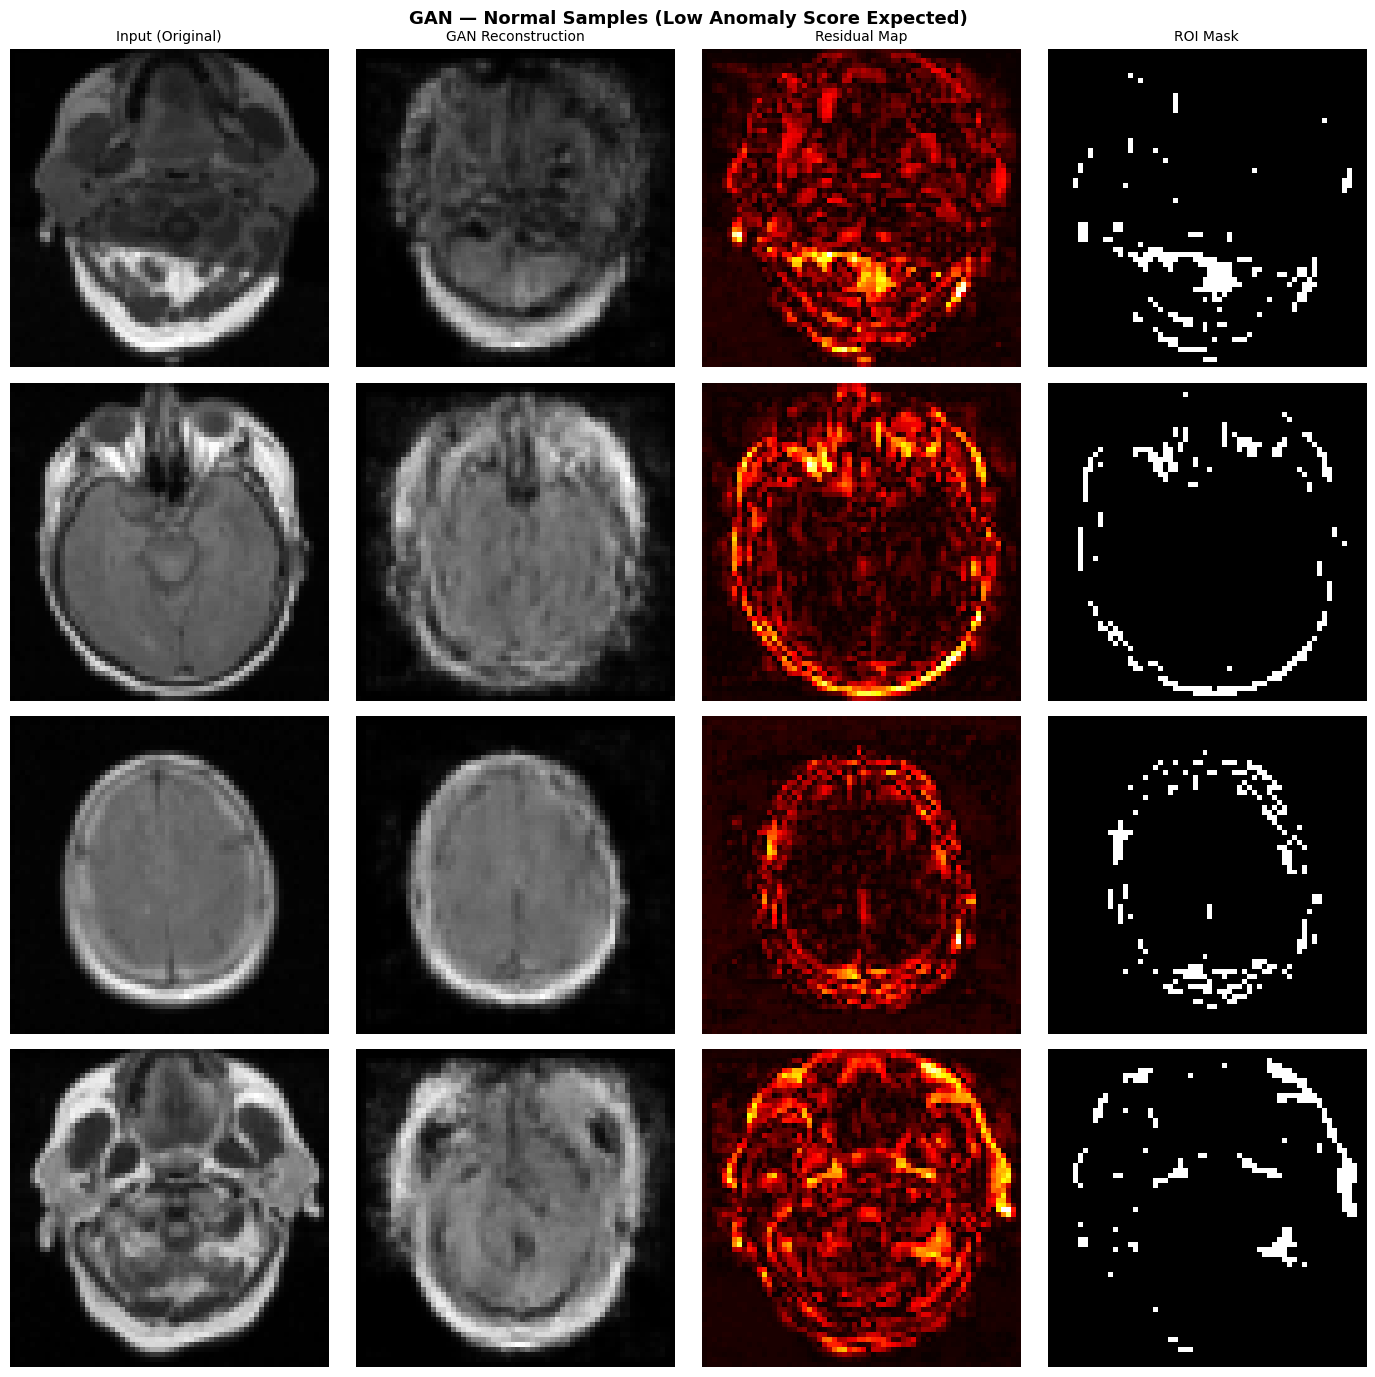

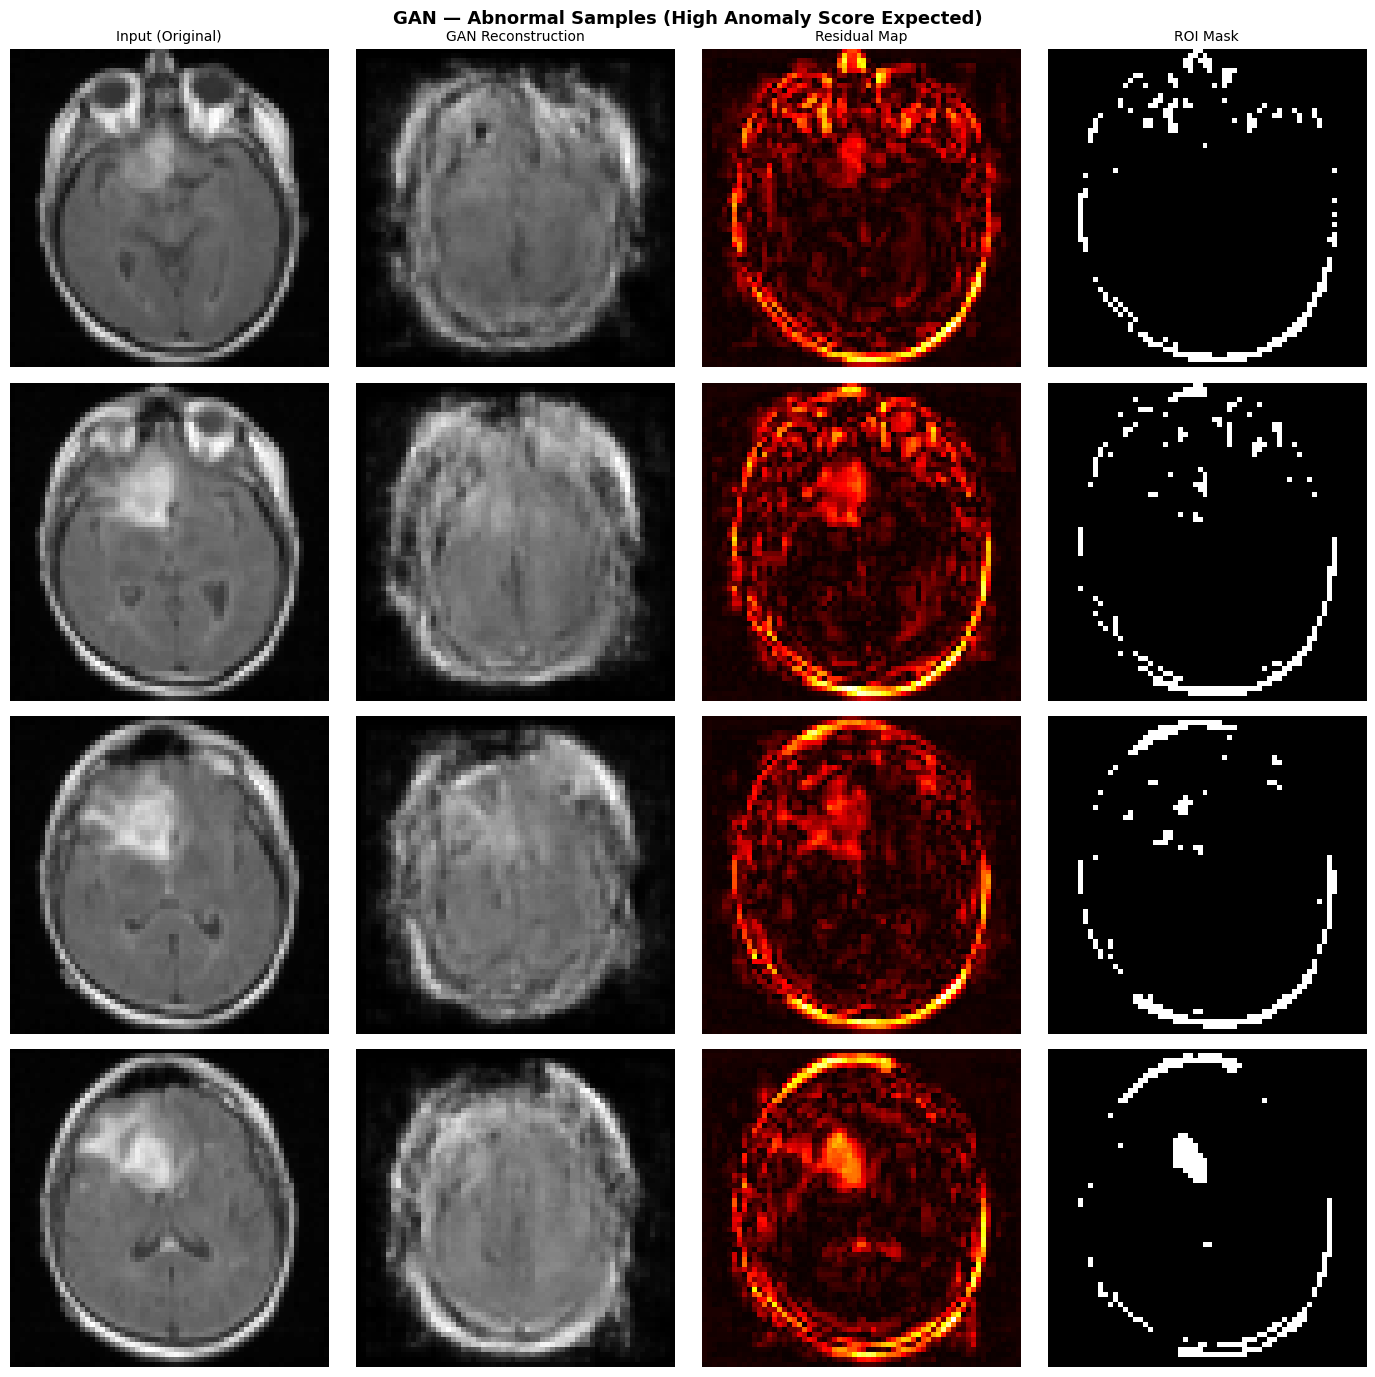

In [23]:
def denorm(img):
    """[-1,1] → [0,1]"""
    return (img + 1) / 2

def get_roi_mask(residual_np, percentile=95):
    """Threshold residual map at top percentile to get binary ROI."""
    threshold = np.percentile(residual_np, percentile)
    return (residual_np > threshold).astype(np.uint8)

def plot_reconstruction_grid(results, title, filename):
    n = len(results)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5*n))
    if n == 1: axes = [axes]
    col_titles = ['Input (Original)', 'GAN Reconstruction', 'Residual Map', 'ROI Mask']

    for row, result in enumerate(results):
        orig, recon, resid, score = result[0], result[1], result[2], result[3]
        # ↑ index directly — safe regardless of how many extra fields exist

        orig_d  = denorm(orig)
        recon_d = denorm(recon)
        roi     = get_roi_mask(resid)

        for col, (img, cmap) in enumerate([
            (orig_d, 'gray'), (recon_d, 'gray'),
            (resid,  'hot'),  (roi,     'gray')
        ]):
            axes[row][col].imshow(img, cmap=cmap)
            axes[row][col].axis('off')
            if row == 0:
                axes[row][col].set_title(col_titles[col], fontsize=10)

        axes[row][0].set_ylabel(f'Score: {score:.4f}', fontsize=8)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_reconstruction_grid(norm_results,
                         'GAN — Normal Samples (Low Anomaly Score Expected)',
                         'gan_roi_normal.png')
plot_reconstruction_grid(abn_results,
                         'GAN — Abnormal Samples (High Anomaly Score Expected)',
                         'gan_roi_abnormal.png')

## 15. Heatmap Overlay — Anomaly Region on Original MRI
Residual map overlaid in colour on greyscale MRI for clinical interpretability.

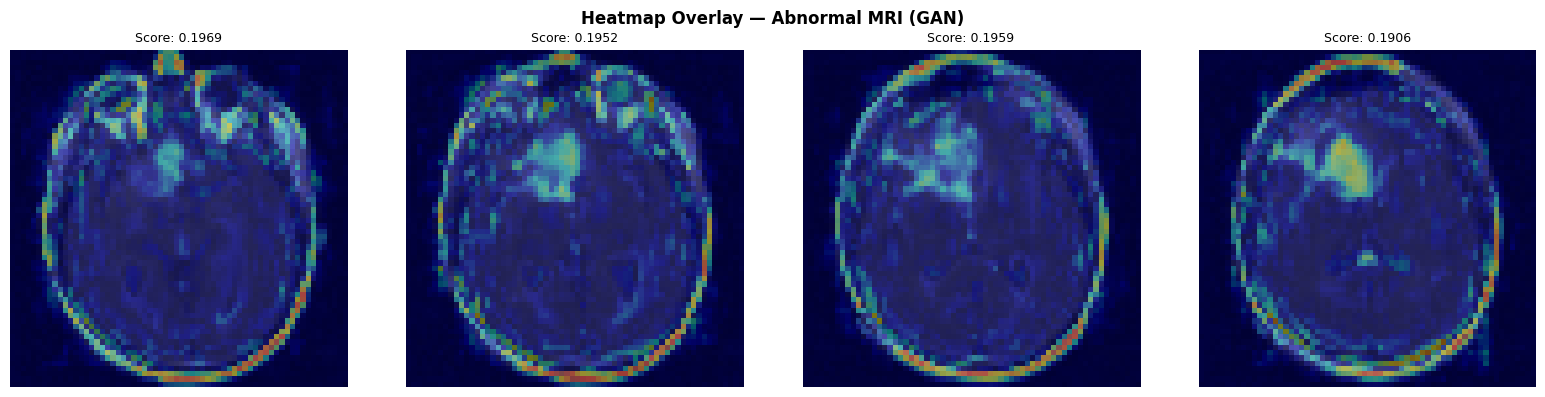

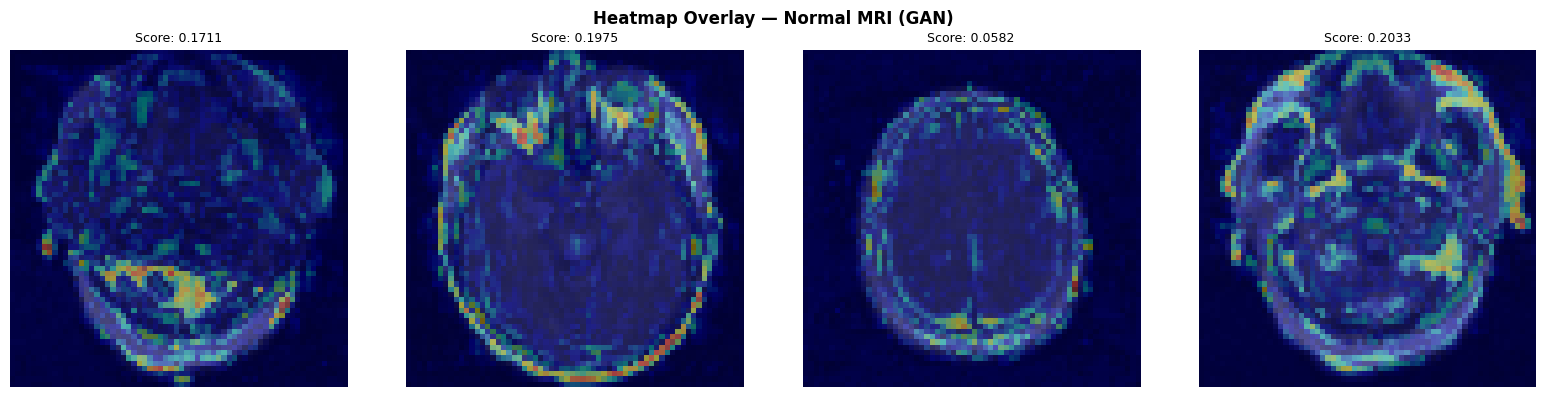

In [25]:
def plot_heatmap_overlay(results, title, filename):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]

    for ax, result in zip(axes, results):
        orig, recon, resid, score = result[0], result[1], result[2], result[3]
        # ↑ same fix as reconstruction grid

        orig_d     = (denorm(orig) * 255).astype(np.uint8)
        resid_norm = ((resid - resid.min()) /
                      (resid.max() - resid.min() + 1e-8) * 255).astype(np.uint8)

        orig_bgr = cv2.cvtColor(orig_d, cv2.COLOR_GRAY2BGR)
        heatmap  = cv2.applyColorMap(resid_norm, cv2.COLORMAP_JET)
        overlay  = cv2.addWeighted(orig_bgr, 0.6, heatmap, 0.4, 0)

        ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Score: {score:.4f}', fontsize=9)
        ax.axis('off')

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_heatmap_overlay(abn_results,  'Heatmap Overlay — Abnormal MRI (GAN)', 'heatmap_abnormal.png')
plot_heatmap_overlay(norm_results, 'Heatmap Overlay — Normal MRI (GAN)',   'heatmap_normal.png')

## 16. Reconstruction Error Distribution
Histogram of anomaly scores for normal vs abnormal slices.  
**Good separation = GAN has learnt the normal distribution well.**

Computing scores for normal set...


Scoring: 100%|██████████| 30/30 [02:53<00:00,  5.79s/it]


Computing scores for abnormal set...


Scoring: 100%|██████████| 30/30 [02:54<00:00,  5.80s/it]


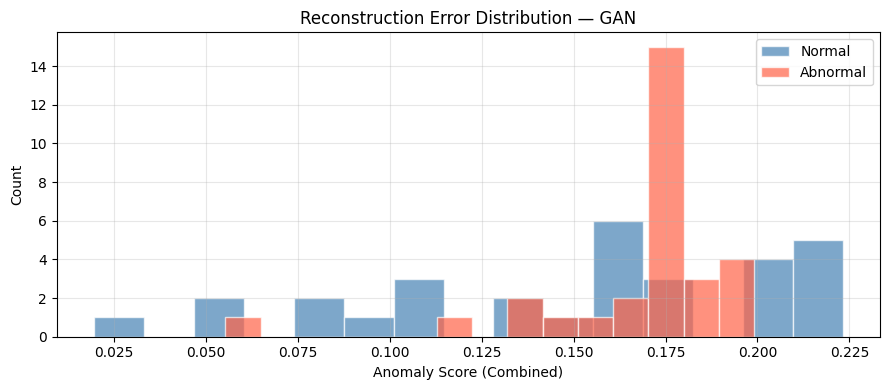

Normal   mean score: 0.1504 ± 0.0547
Abnormal mean score: 0.1682 ± 0.0276
Separation ratio   : 1.12x


In [29]:
def batch_scores(dataset, n=30):
    scores = []
    for i in tqdm(range(min(n, len(dataset))), desc='Scoring'):
        x      = dataset[i]
        result = anogan.score(x)   # ← don't unpack, just index
        score  = result[1]         # index 1 is always the combined score
        scores.append(score)
    return scores

print('Computing scores for normal set...')
norm_scores = batch_scores(test_normal,   n=30)
print('Computing scores for abnormal set...')
abn_scores  = batch_scores(test_abnormal, n=30)

plt.figure(figsize=(9, 4))
plt.hist(norm_scores, bins=15, alpha=0.7, label='Normal',
         color='steelblue', edgecolor='white')
plt.hist(abn_scores,  bins=15, alpha=0.7, label='Abnormal',
         color='tomato',    edgecolor='white')
plt.xlabel('Anomaly Score (Combined)')
plt.ylabel('Count')
plt.title('Reconstruction Error Distribution — GAN')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reconstruction_error_plot.png', dpi=150)
plt.show()

print(f'Normal   mean score: {np.mean(norm_scores):.4f} ± {np.std(norm_scores):.4f}')
print(f'Abnormal mean score: {np.mean(abn_scores):.4f} ± {np.std(abn_scores):.4f}')
print(f'Separation ratio   : {np.mean(abn_scores)/np.mean(norm_scores):.2f}x')

## 17. Latent Space Visualisation (t-SNE)
Optimised `z*` vectors for normal and abnormal samples projected to 2D.  
If clustering occurs → GAN latent space separates normal from anomalous.

Extracting latent vectors — normal samples...


Extracting z*: 100%|██████████| 30/30 [00:23<00:00,  1.27it/s]


Extracting latent vectors — abnormal samples...


Extracting z*: 100%|██████████| 30/30 [00:23<00:00,  1.27it/s]


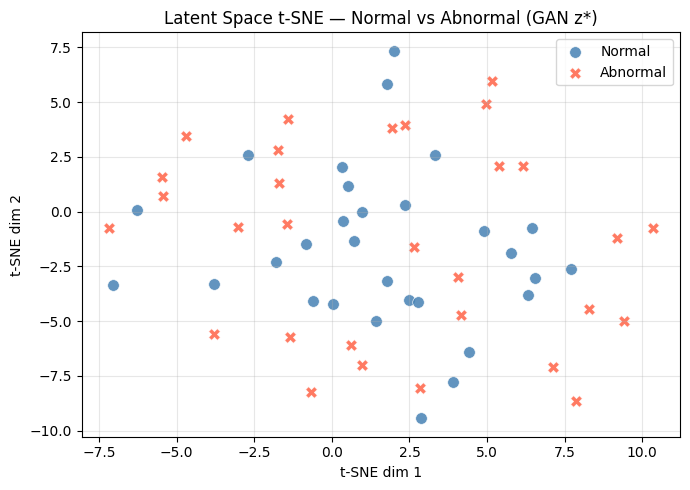

In [30]:
def get_optimal_z(dataset, n=30):
    """Extract best z* for each image using trained AnoGAN."""
    zs = []
    for i in tqdm(range(min(n, len(dataset))), desc='Extracting z*'):
        x = dataset[i]
        # Use fewer iters here — just need z for visualisation not perfect recon
        if x.dim() == 3:
            x = x.unsqueeze(0)
        x = x.to(DEVICE)

        z = nn.Parameter(torch.randn(1, LATENT_DIM, 1, 1, device=DEVICE))
        opt = optim.Adam([z], lr=5e-3)

        for _ in range(300):   # 300 iters enough for z extraction
            opt.zero_grad()
            loss = nn.functional.l1_loss(anogan.G(z), x)
            loss.backward()
            opt.step()

        zs.append(z.detach().cpu().numpy().flatten())
    return np.array(zs)

print('Extracting latent vectors — normal samples...')
z_normal   = get_optimal_z(test_normal,   n=30)
print('Extracting latent vectors — abnormal samples...')
z_abnormal = get_optimal_z(test_abnormal, n=30)

from sklearn.manifold import TSNE

Z_all  = np.vstack([z_normal, z_abnormal])
labels = ['Normal']*len(z_normal) + ['Abnormal']*len(z_abnormal)

tsne = TSNE(n_components=2, random_state=42, perplexity=10)
Z_2d = tsne.fit_transform(Z_all)

plt.figure(figsize=(7, 5))
for lbl, color, marker in [('Normal', 'steelblue', 'o'),
                             ('Abnormal', 'tomato',    'X')]:
    idx = [i for i, l in enumerate(labels) if l == lbl]
    plt.scatter(Z_2d[idx, 0], Z_2d[idx, 1],
                c=color, label=lbl, marker=marker,
                s=70, alpha=0.85, edgecolors='white', linewidths=0.5)
plt.title('Latent Space t-SNE — Normal vs Abnormal (GAN z*)')
plt.xlabel('t-SNE dim 1'); plt.ylabel('t-SNE dim 2')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('latent_space_tsne.png', dpi=150)
plt.show()

## 18. Latent Distribution Histogram
Distribution of individual latent dimensions for normal vs abnormal. Should follow ~N(0,1) for normal; shifted for abnormal.

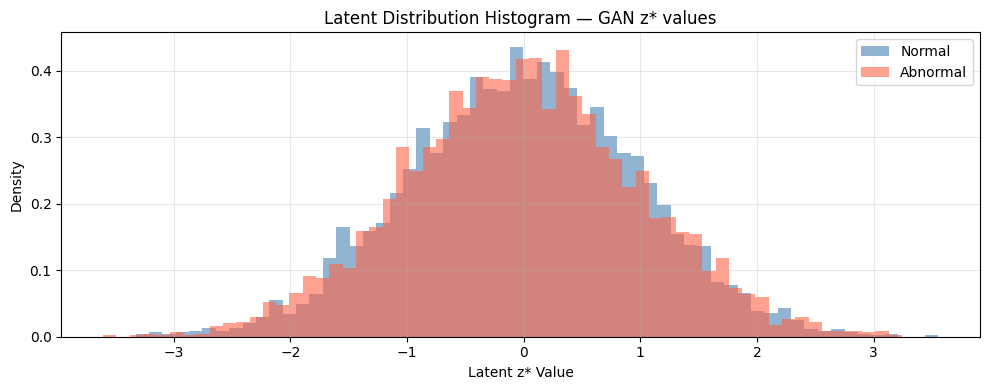

Normal   z* mean: -0.0032  std: 0.9855
Abnormal z* mean: -0.0155  std: 1.0057


In [31]:
plt.figure(figsize=(10, 4))
plt.hist(z_normal.flatten(),   bins=60, alpha=0.6,
         label='Normal',   color='steelblue', density=True)
plt.hist(z_abnormal.flatten(), bins=60, alpha=0.6,
         label='Abnormal', color='tomato',    density=True)
plt.xlabel('Latent z* Value')
plt.ylabel('Density')
plt.title('Latent Distribution Histogram — GAN z* values')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('latent_distribution_histogram.png', dpi=150)
plt.show()

print(f'Normal   z* mean: {z_normal.mean():.4f}  std: {z_normal.std():.4f}')
print(f'Abnormal z* mean: {z_abnormal.mean():.4f}  std: {z_abnormal.std():.4f}')

## 19. ROI Quality Analysis
Quantitative metrics for the ROI obtained from GAN:  
- **Smoothness** — inverse of Laplacian variance (higher = smoother mask)  
- **Edge Pixel Count** — Canny edges within ROI  
- **Noise Ratio** — isolated pixel count / total ROI pixels

In [35]:
def compute_roi_metrics(roi_mask, residual=None):
    """roi_mask: binary uint8 numpy array (0 or 1)."""
    mask_u8 = (roi_mask * 255).astype(np.uint8)

    # Smoothness — computed on residual map if available
    # binary mask Laplacian is always near-zero — not meaningful
    if residual is not None:
        resid_u8   = ((residual - residual.min()) /
                      (residual.max() - residual.min() + 1e-8) * 255).astype(np.uint8)
        lap        = cv2.Laplacian(resid_u8, cv2.CV_64F)
        smoothness = round(1.0 / (lap.var() + 1e-8), 6)
    else:
        lap        = cv2.Laplacian(mask_u8, cv2.CV_64F)
        smoothness = round(1.0 / (lap.var() + 1e-8), 6)

    # Edge pixel count via Canny on mask
    edges      = cv2.Canny(mask_u8, 50, 150)
    edge_count = int(edges.sum() / 255)

    # Noise ratio — small connected components
    n_labels, _, stats, _ = cv2.connectedComponentsWithStats(
                                mask_u8, connectivity=8)
    small_cc    = sum(1 for i in range(1, n_labels)
                      if stats[i, cv2.CC_STAT_AREA] < 5)
    noise_ratio = round(small_cc / max(n_labels - 1, 1), 4)

    return {'smoothness':       smoothness,
            'edge_pixel_count': edge_count,
            'noise_ratio':      noise_ratio}

# ── Updated analysis loop — pass residual too ─────────────────
rows = []
for label, results in [('Normal',   norm_results[:2]),
                        ('Abnormal', abn_results[:2])]:
    for i, result in enumerate(results):
        orig, recon, resid, score = result[0], result[1], result[2], result[3]
        roi  = get_roi_mask(resid)
        mets = compute_roi_metrics(roi, residual=resid)  # ← pass resid
        rows.append({'Type': label, 'Sample': i+1,
                     'Anomaly Score': round(score, 5), **mets})

df_analysis = pd.DataFrame(rows)
print(df_analysis.to_string(index=False))

    Type  Sample  Anomaly Score  smoothness  edge_pixel_count  noise_ratio
  Normal       1        0.17113    0.000189               303       0.8462
  Normal       2        0.19751    0.000123               295       0.6000
Abnormal       1        0.19686    0.000160               280       0.7188
Abnormal       2        0.19521    0.000140               339       0.7568


## 20. ROI Metrics Summary Table & Bar Chart

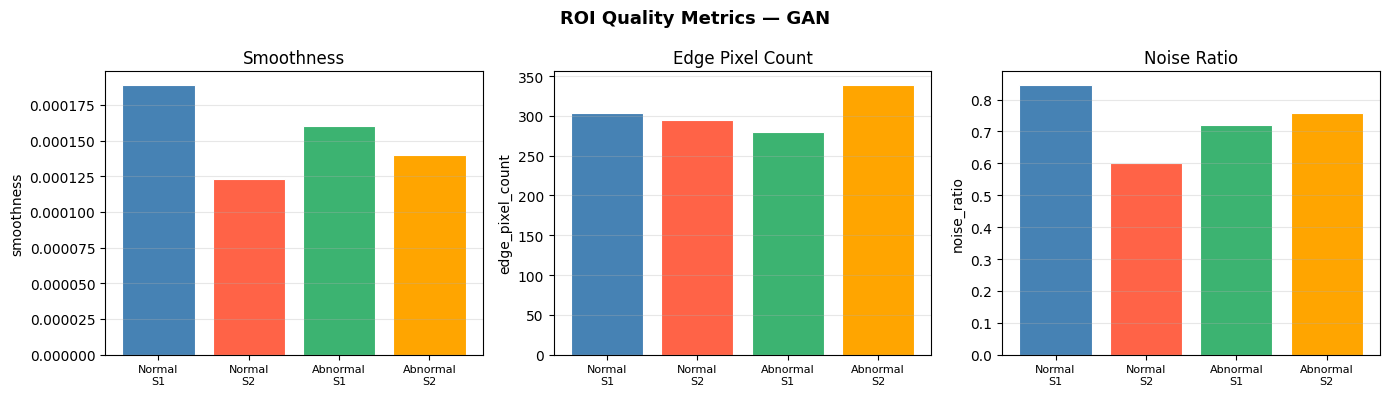

,Type,Sample,Anomaly Score,smoothness,edge_pixel_count,noise_ratio
0,Normal,1,0.17113,0.000189,303,0.8462
1,Normal,2,0.19751,0.000123,295,0.6000
2,Abnormal,1,0.19686,0.000160,280,0.7188
3,Abnormal,2,0.19521,0.000140,339,0.7568


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = ['smoothness', 'edge_pixel_count', 'noise_ratio']
colors    = ['steelblue', 'tomato', 'mediumseagreen', 'orange']
sample_labels = df_analysis.apply(lambda r: f"{r['Type']}\nS{r['Sample']}", axis=1)

for ax, metric in zip(axes, metrics):
    ax.bar(sample_labels, df_analysis[metric], color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ROI Quality Metrics — GAN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
display(df_analysis)